In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import osmnx as ox
import h3

import geopandas as gpd
from shapely.geometry import Polygon
# from google.colab import drive
#drive.mount('/content/drive')

%matplotlib inline

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

WINE = "#8B2635"
RED = "#C0392B"
ORANGE = "#E67E22"
GOLD = "#D4AC0D"
GRAY = "#7F8C8D"
DARK = "#34495E"

In [2]:
df = pd.read_csv('df_hour_clean.csv')
df.head(5)

,Unnamed: 0,folio,fecha_creacion,hora_creacion,dia_semana,fecha_cierre,hora_cierre,tipo_incidente_c4,incidente_c4,alcaldia_inicio,codigo_cierre,clas_con_f_alarma,tipo_entrada,alcaldia_cierre,alcaldia_catalogo,colonia_catalogo,longitud,latitud,dt_creacion,dt_cierre,duracion_min,hora_creacion_imputada,coord_valida,outlier_duracion,anio,mes,hora,es_fin_de_semana,franja_horaria,es_afirmativo,es_duplicado_c5,anio_incompleto,target,fecha_hora,hora_agrupada,fecha_hora_rango
0,199882,C5/200101/04018,2020-01-01,08:27:26,Miércoles,2020-01-01,08:39:56,Accidente,Choque sin lesionados,IZTAPALAPA,N,EMERGENCIA,LLAMADA DEL 911,IZTAPALAPA,Iztapalapa,Lomas De San Lorenzo,-99.068480,19.326660,2020-01-01 08:27:26,2020-01-01 08:39:56,12.500000,False,True,False,2020.0,1.0,8.0,False,Mañana (6-11),False,False,False,0,2020-01-01 08:27:26,09:00:00,2020-01-01 09:00:00
1,199883,C5/200101/03344,2020-01-01,06:25:30,Miércoles,2020-01-01,06:44:49,Accidente,Choque con prensados,IZTAPALAPA,N,URGENCIAS MEDICAS,LLAMADA DEL 911,IZTAPALAPA,Iztapalapa,Pueblo Culhuacan,-99.108971,19.336779,2020-01-01 06:25:30,2020-01-01 06:44:49,19.316667,False,True,False,2020.0,1.0,6.0,False,Mañana (6-11),False,False,False,0,2020-01-01 06:25:30,07:00:00,2020-01-01 07:00:00
2,199884,IZ/200101/04263,2020-01-01,09:27:54,Miércoles,2020-01-01,14:08:18,Accidente,Choque sin lesionados,IZTAPALAPA,A,EMERGENCIA,RADIO,IZTAPALAPA,Iztapalapa,Lomas De San Lorenzo,-99.069400,19.326210,2020-01-01 09:27:54,2020-01-01 14:08:18,280.400000,False,True,False,2020.0,1.0,9.0,False,Mañana (6-11),True,False,False,1,2020-01-01 09:27:54,10:00:00,2020-01-01 10:00:00
3,199886,IZ/200101/03198,2020-01-01,05:59:07,Miércoles,2020-01-01,07:36:12,Accidente,Choque sin lesionados,IZTAPALAPA,A,EMERGENCIA,BOTÓN DE AUXILIO,IZTAPALAPA,Iztapalapa,Pueblo Sta Cruz Meyehualco,-99.047623,19.341621,2020-01-01 05:59:07,2020-01-01 07:36:12,97.083333,False,True,False,2020.0,1.0,5.0,False,Madrugada (0-5),True,False,False,1,2020-01-01 05:59:07,06:00:00,2020-01-01 06:00:00
4,199887,C5/200101/08233,2020-01-01,19:27:08,Miércoles,2020-01-01,19:52:22,Accidente,Choque sin lesionados,IZTAPALAPA,N,EMERGENCIA,LLAMADA DEL 911,IZTAPALAPA,Iztapalapa,Año De Juarez,-99.072910,19.317710,2020-01-01 19:27:08,2020-01-01 19:52:22,25.233333,False,True,False,2020.0,1.0,19.0,False,Noche (18-21),False,False,False,0,2020-01-01 19:27:08,20:00:00,2020-01-01 20:00:00


In [3]:
df.shape

(145313, 36)

## 1. Ventana temporal y filtros de calidad

Se delimita a 2022 en adelante (post-pandemia, decisión documentada) y se
excluyen registros de baja calidad. **Punto a confirmar contigo:** este
filtro usa `target == 1` (incidente confirmado) para excluir falsas
alarmas / códigos de cierre negativos (`codigo_cierre == 'N'`). Si el
criterio real de "incidente válido" en tu limpieza es otro, ajusta la
máscara antes de seguir — cambia el n final y por tanto todo lo que
sigue.

In [4]:
def filtrar_dataset(df: pd.DataFrame, anio_inicio: int) -> pd.DataFrame:
    """
    Aplica la ventana temporal decidida y los filtros de calidad.

    Filtros:
    - anio >= anio_inicio: excluye el periodo pre/pandemia (cambio de régimen).
    - coord_valida: descarta coordenadas geocodificadas incorrectamente.
    - es_duplicado_c5 == False: evita contar dos veces el mismo evento.
    - target == 1: solo incidentes confirmados (excluye falsas alarmas /
      códigos de cierre negativos), que no deberían contar como siniestro
      real para el análisis espacial.
    """
    mask = (
        (df['anio'] >= anio_inicio)
        & (df['coord_valida'] == True)
        & (df['es_duplicado_c5'] == False)
        & (df['target'] == 1)
    )
    return df.loc[mask].copy()


df_filtrado = filtrar_dataset(df, anio_inicio=2021)
print(f"Registros tras filtrado: {len(df_filtrado):,} de {len(df):,} originales "
      f"({len(df_filtrado) / len(df) * 100:.1f}%)")


Registros tras filtrado: 38,697 de 145,313 originales (26.6%)


## 2. Librerías de estadística espacial

`libpysal` (pesos espaciales) + `esda` (Moran's I, LISA, Getis-Ord Gi*) +
`splot` (visualización). Instala si falta:
`pip install libpysal esda splot h3`.

**Nota de versión de `h3-py`:** el código de abajo usa la API v4
(`latlng_to_cell`, `cell_to_boundary`, `grid_disk`, `polygon_to_cells`).
Si tu entorno tiene h3-py v3, los nombres equivalentes son
`geo_to_h3`, `h3_to_geo_boundary`, `k_ring`, `polyfill`. Verifica con
`h3.__version__` antes de ejecutar.

In [5]:
import libpysal
from esda.moran import Moran, Moran_Local
from esda.getisord import G_Local
from splot.esda import moran_scatterplot, lisa_cluster

print("h3-py version:", h3.__version__)


h3-py version: 4.5.0


## 3. Malla H3 completa sobre Iztapalapa (Resolución 8)

Importante: para Moran's I / Getis-Ord Gi* se necesita la malla **completa**
del área de estudio (incluyendo celdas sin incidentes), no solo las celdas
con al menos un evento. Omitir las celdas en cero deja una matriz de
vecinos incompleta y sesga el estadístico. Por eso primero se genera la
malla contra el polígono de la alcaldía y después se agregan los conteos.

In [6]:
H3_RESOLUTION = 9  # ~0.74 km^2 por celda (consistente con Marco Teórico)


def obtener_limite_iztapalapa() -> gpd.GeoDataFrame:
    """Descarga el polígono administrativo de Iztapalapa vía OSMnx/Nominatim."""
    gdf = ox.geocode_to_gdf("Iztapalapa, Ciudad de México, México")
    return gdf


def generar_malla_completa(gdf_limite: gpd.GeoDataFrame, resolucion: int = H3_RESOLUTION) -> list:
    """
    Genera TODAS las celdas H3 que cubren el polígono de Iztapalapa.
    Ajusta 'polygon_to_cells' / 'geo_to_h3shape' al API real de tu versión
    de h3-py si esta línea marca error (ver nota de versión arriba).
    """
    geom = gdf_limite.geometry.unary_union
    h3shape = h3.geo_to_h3shape(geom.__geo_interface__)
    celdas = h3.polygon_to_cells(h3shape, resolucion)
    return list(celdas)


iztapalapa_gdf = obtener_limite_iztapalapa()
celdas_h3_iztapalapa = generar_malla_completa(iztapalapa_gdf)
print(f"Celdas H3 (res {H3_RESOLUTION}) cubriendo Iztapalapa: {len(celdas_h3_iztapalapa)}")


Celdas H3 (res 9) cubriendo Iztapalapa: 931


C:\Users\jesus\AppData\Local\Temp\ipykernel_33976\3128644597.py:16: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = gdf_limite.geometry.unary_union


## 4. Asignación de incidentes a celdas H3 y agregación

Se agrega el **conteo total por celda a lo largo de toda la ventana
2022-2024** (no celda-hora). Es una pregunta distinta a la que resuelve el
modelo de forecasting: aquí se busca *dónde* se concentran los incidentes,
no *cuándo*. Usar la granularidad celda-hora (con ~96.5% de ceros) metería
zero-inflation trivial en la prueba y sesgaría el resultado.

In [7]:
def asignar_celda_h3(df: pd.DataFrame, resolucion: int = H3_RESOLUTION) -> pd.DataFrame:
    """Asigna a cada incidente puntual su celda H3 correspondiente."""
    df = df.copy()
    df['h3_id'] = df.apply(
        lambda row: h3.latlng_to_cell(row['latitud'], row['longitud'], resolucion),
        axis=1,
    )
    return df


def _hex_boundary_lonlat(h: str) -> list[tuple[float, float]]:
    """
    Shapely espera (x, y) = (lng, lat), así
    que se invierte manualmente en vez de depender del flag.
    """
    return [(lng, lat) for lat, lng in h3.cell_to_boundary(h)]


def construir_gdf_h3_completo(df: pd.DataFrame, celdas_malla: list) -> gpd.GeoDataFrame:
    """
    Construye el GeoDataFrame de análisis: una fila por cada celda de la
    malla completa (incluye ceros), con el conteo total de incidentes y su
    polígono para visualización.
    """
    conteo = df.groupby('h3_id').size().rename('conteo_incidentes')
    malla = pd.DataFrame({'h3_id': celdas_malla}).set_index('h3_id')
    malla = malla.join(conteo).fillna(0)
    malla['conteo_incidentes'] = malla['conteo_incidentes'].astype(int)
    malla = malla.reset_index()

    malla['geometry'] = malla['h3_id'].apply(lambda h: Polygon(_hex_boundary_lonlat(h)))
    gdf = gpd.GeoDataFrame(malla, geometry='geometry', crs='EPSG:4326')
    return gdf


df_filtrado = asignar_celda_h3(df_filtrado)
gdf_h3 = construir_gdf_h3_completo(df_filtrado, celdas_h3_iztapalapa)

print(f"Celdas totales en la malla: {len(gdf_h3)}")
print(f"Celdas con al menos un incidente: {(gdf_h3['conteo_incidentes'] > 0).sum()}")

Celdas totales en la malla: 931
Celdas con al menos un incidente: 875


## 5. Matriz de pesos espaciales (vecinos nativos H3)

Se usa el anillo k=1 de H3 (`grid_disk`) en vez de contigüidad geométrica:
es exacto para una malla hexagonal y evita errores de precisión de punto
flotante en los bordes de los polígonos.

In [8]:
def construir_pesos_espaciales(h3_ids: list) -> "libpysal.weights.W":
    """
    Matriz de pesos W a partir de los vecinos nativos H3 (anillo k=1: hasta
    6 vecinos por celda interior). Se recortan los vecinos que caen fuera
    del área de estudio (efecto de borde esperado, no un error).
    Fila-estandarizada ('r'): requerida por Moran's I / Getis-Ord Gi*.
    """
    celdas_validas = set(h3_ids)
    vecinos = {}
    for celda in h3_ids:
        anillo = set(h3.grid_disk(celda, 1)) - {celda}
        vecinos[celda] = list(anillo & celdas_validas)

    w = libpysal.weights.W(vecinos)
    w.transform = 'r'

    if w.islands:
        print(f"Celdas aisladas (0 vecinos dentro de la malla): {len(w.islands)}")
        print("-> Esto alimenta directamente la decisión de 'tratamiento de hexágonos aislados'.")

    return w


w = construir_pesos_espaciales(gdf_h3['h3_id'].tolist())


## 6. Pruebas de autocorrelación espacial

Las tres pruebas usan `permutations=999` (Monte Carlo condicional) en vez
del z-test analítico de forma cerrada: los conteos de incidentes no son
normales (zero-inflation documentado), así que el p-value de forma cerrada
no es válido aquí.

In [9]:
def prueba_moran_global(y: np.ndarray, w: "libpysal.weights.W", permutaciones: int = 9999) -> Moran:
    """
    Moran's I global: ¿existe autocorrelación espacial en general?
    H0: distribución espacial aleatoria. Valida (o no) el supuesto base
    de que un GCN tiene señal vecinal que propagar a esta resolución.

    Nota de reproducibilidad: la clase Moran de esda NO acepta un
    parámetro `seed` (a diferencia de Moran_Local/G_Local) -- genera sus
    permutaciones con np.random.permutation sobre el estado GLOBAL de
    NumPy. Por eso se fija np.random.seed() aquí mismo, justo antes de
    instanciarla, para que p_sim sea reproducible entre corridas.
    """
    np.random.seed(42)
    moran = Moran(y, w, permutations=permutaciones)
    print(f"Moran's I global : {moran.I:.4f}")
    print(f"p-value (sim)    : {moran.p_sim:.4f}")
    print(f"z-score (sim)    : {moran.z_sim:.4f}")
    return moran


In [10]:
def prueba_lisa(y: np.ndarray, w: "libpysal.weights.W", permutaciones: int = 999) -> Moran_Local:
    """
    Local Moran's I (LISA): clasifica cada celda en HH/LL (clusters) o
    HL/LH (outliers espaciales). Informa directamente la decisión de
    tratamiento de hexágonos aislados/atípicos en la matriz de adyacencia.
    """
    lisa = Moran_Local(y, w, permutations=permutaciones, seed=42)
    return lisa


In [11]:
def prueba_getis_ord(y: np.ndarray, w: "libpysal.weights.W", permutaciones: int = 9999) -> G_Local:
    """
    Getis-Ord Gi*: localiza hot spots / cold spots estadísticamente
    significativos. star=1.0 fija el self-weight explícitamente en vez de
    dejar que la librería lo infiera (evita el UserWarning de esda sobre
    pesos sin diagonal).
    """
    gi = G_Local(y, w, star=1.0, permutations=permutaciones, seed=42)  # self-weight explícito
    return gi


In [12]:
y = gdf_h3['conteo_incidentes'].values.astype(float)

moran = prueba_moran_global(y, w)
lisa = prueba_lisa(y, w)
gi = prueba_getis_ord(y, w)

# Se anexan los resultados al GeoDataFrame para mapeo en la siguiente sección
gdf_h3['lisa_cuadrante'] = lisa.q       # 1=HH, 2=LH, 3=LL, 4=HL
gdf_h3['lisa_p'] = lisa.p_sim
gdf_h3['gi_z'] = gi.Zs
gdf_h3['gi_p'] = gi.p_sim


Moran's I global : -0.0338
p-value (sim)    : 0.0405
z-score (sim)    : -1.6876


## 7. Visualizaciones

d:\Lic Ciencia de Datos\TT C5\venv\Lib\site-packages\spreg\diagnostics.py:620: ComplexWarning: Casting complex values to real discards the imaginary part
  ci_result = sqrt(max_eigval / min_eigval)


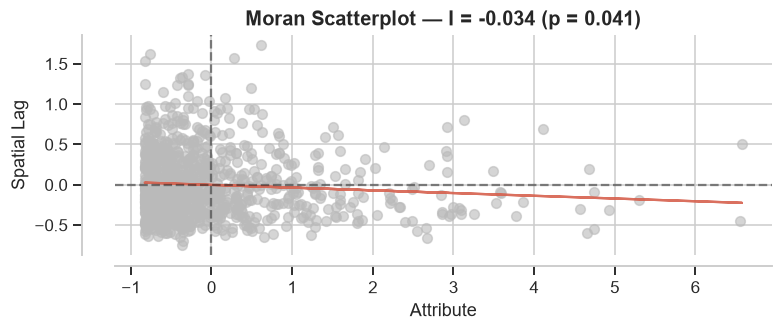

In [13]:
# Moran scatterplot: eje x = valor estandarizado, eje y = rezago espacial
# (promedio de vecinos). La pendiente de la recta ajustada es el propio I.
fig, ax = moran_scatterplot(moran, aspect_equal=True)
ax.set_title(f"Moran Scatterplot — I = {moran.I:.3f} (p = {moran.p_sim:.3f})")
plt.tight_layout()
plt.show()


In [14]:
# Títulos
    # Agregar los logos.
    # Agregar la carrera.
# Limitantes mandarlo a una nueva hoja.
# Todos los títulos, solo la primer letra va en mayúscula.
# El segundo y terecer parrafo están juntos y hay un punto y aparte, hay que corregirlo. Título 1.
    # Agregar una tablita al final del estado del arte.
    # Al final ponemos una propuesta que estamos haciendo.
# El número de accidentes del INEGI, a nivel general de número de incidentes viales, poner datos estadísticos, en el capítulo 2.
    # En las aseguradores de parque vehicular podemos encontrar registros de choques, colisiones, robos. (Con eso fundamentamos que eso es importante).
# 2.1.3 cambiar cita.
# 2.2 Inteligencia artificial
    # Aprendizaje supervizado y no-supervizado
    # Luego explicar lo de aprendizaje profundo
    # Podemos explicar esto de la red neuronal.
    # Buscar imágenes de las redes neuronales de la GCNN , LSTM.
# Falta el índice de ecuaciones. (ya hay ecuaciones de vía urbano)
# poner: por sus siglas en inglés (VRP)
# NP - duros
# En el marco teórico de agregar estadísticas, métricas de vañidación, estadísticas (puede ser sección 2.6)
# Entre metodología y fases de metodología va texto.(En general entre sección y subsección).
# Falta en el estado del arte los lenguajes de programación que vamos a utilizar.
# Después de la subsección Fases de la metodología debería haber un apartado de banco de datos o base de de datos.
# Agregar en el marco conceptual las librerías que estamos usando.
# En la metodología hay que explicar mucho más lo que estamos haciendo. Hay checar eso de fuente de verdad unificada.
    # En esta fase número 1, poner todo lo que estamos haciendo todo del código fuente.
    # En la sección de resultados ya ponemos los resultados
    # El resultado es como un resumen de la metodología.
    # Si consideramos que una parte del código es muy importante, lo podemos poner o un pseodocódigo.
    # Hacer un diagrama de como se van a llevar acabo las fases.
# Todo lo que nos de la inteligencia artificial, leerlo y escribir por nosotros, checar parrafos de la IA.

# Podemos tener dos ventanas de tiempo, antes y después de la pandemia.
# Verificar si hacen match con los pocos datos que haya.

# Agregarlo. Limitantes convertirlo a limitaciones.
# antes de pandemia y después de pandemia:
    # Verificar en train test: Libre de fuga
    # Hacer pruebas en un círculo cerrado. Se eliminan los datos de prueba.
    #    

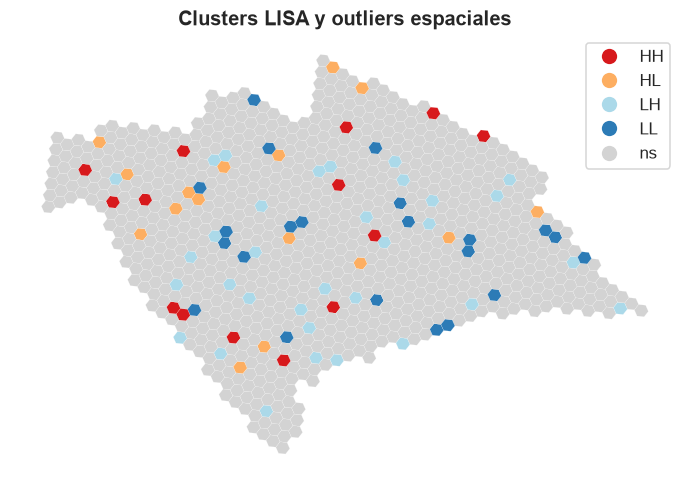

In [15]:
# Mapa de clusters LISA: HH (rojo) y LL (azul) = clusters; HL/LH (naranja) =
# outliers espaciales; gris = no significativo (p >= 0.05).
fig, ax = lisa_cluster(lisa, gdf_h3, p=0.05)
ax.set_title("Clusters LISA y outliers espaciales")
plt.tight_layout()
plt.show()


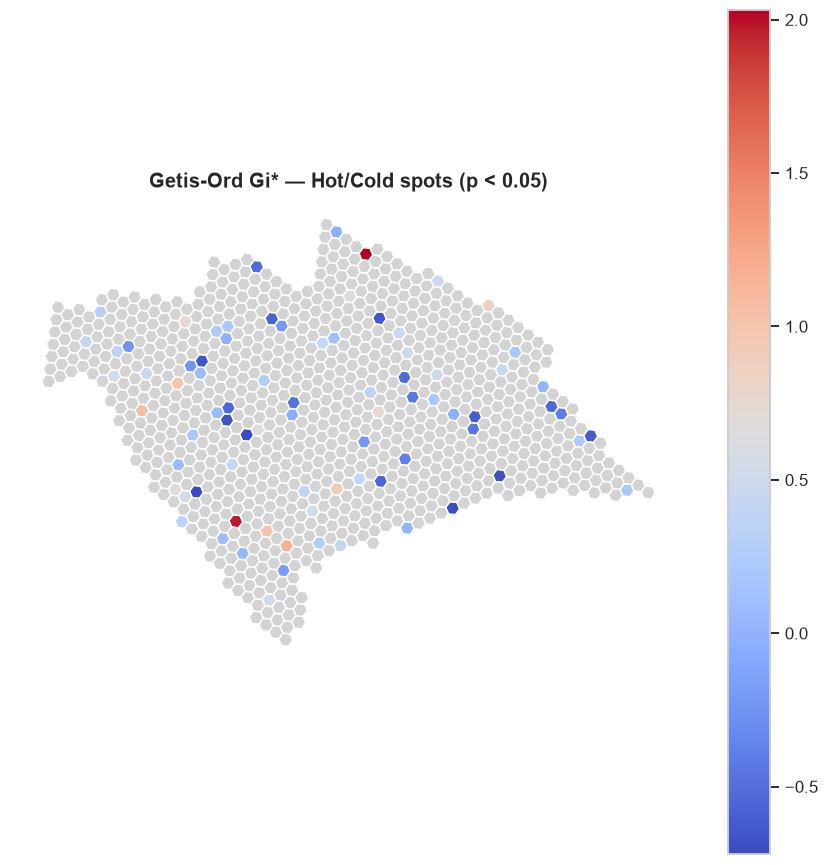

In [16]:
def mapa_hotspots_gi(gdf: gpd.GeoDataFrame, alpha: float = 0.05):
    """
    Mapa choropleth de Gi*, mostrando solo celdas estadísticamente
    significativas (p < alpha); el resto se pinta en gris.
    """
    gdf_plot = gdf.copy()
    gdf_plot.loc[gdf_plot['gi_p'] >= alpha, 'gi_z'] = np.nan

    fig, ax = plt.subplots(figsize=(8, 8))
    gdf_plot.plot(
        column='gi_z', cmap='coolwarm', legend=True,
        missing_kwds={'color': 'lightgrey', 'label': 'No significativo'},
        ax=ax,
    )
    ax.set_title(f"Getis-Ord Gi* — Hot/Cold spots (p < {alpha})")
    ax.axis('off')
    plt.tight_layout()
    plt.show()


mapa_hotspots_gi(gdf_h3)


## 8. Análisis iterativo por resolución H3 (7–12)

Se repite el pipeline completo (malla → agregación → pesos espaciales →
Moran/LISA/Getis-Ord → mapas) para cada resolución en `RESOLUCIONES_PRUEBA`,
reutilizando las funciones ya definidas arriba. `iztapalapa_gdf` y
`df_filtrado` (sin `h3_id`, se reasigna por resolución) se conservan de las
secciones previas.


Resolución H3 = 7
Celdas H3 (res 7) cubriendo Iztapalapa: 19


C:\Users\jesus\AppData\Local\Temp\ipykernel_33976\3128644597.py:16: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = gdf_limite.geometry.unary_union


Celdas totales en la malla: 19
Celdas con al menos un incidente: 19
Moran's I global : -0.0628
p-value (sim)    : 0.4898
z-score (sim)    : -0.0454


d:\Lic Ciencia de Datos\TT C5\venv\Lib\site-packages\spreg\diagnostics.py:620: ComplexWarning: Casting complex values to real discards the imaginary part
  ci_result = sqrt(max_eigval / min_eigval)


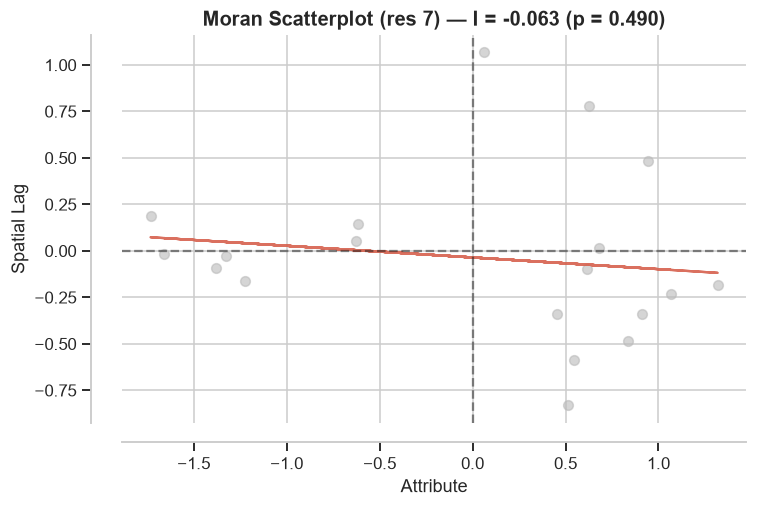

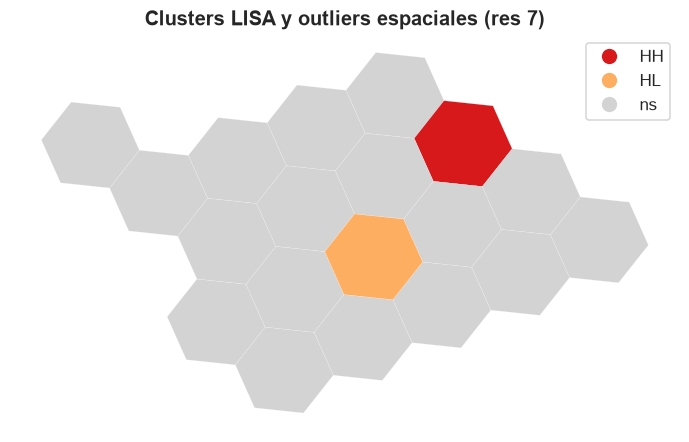

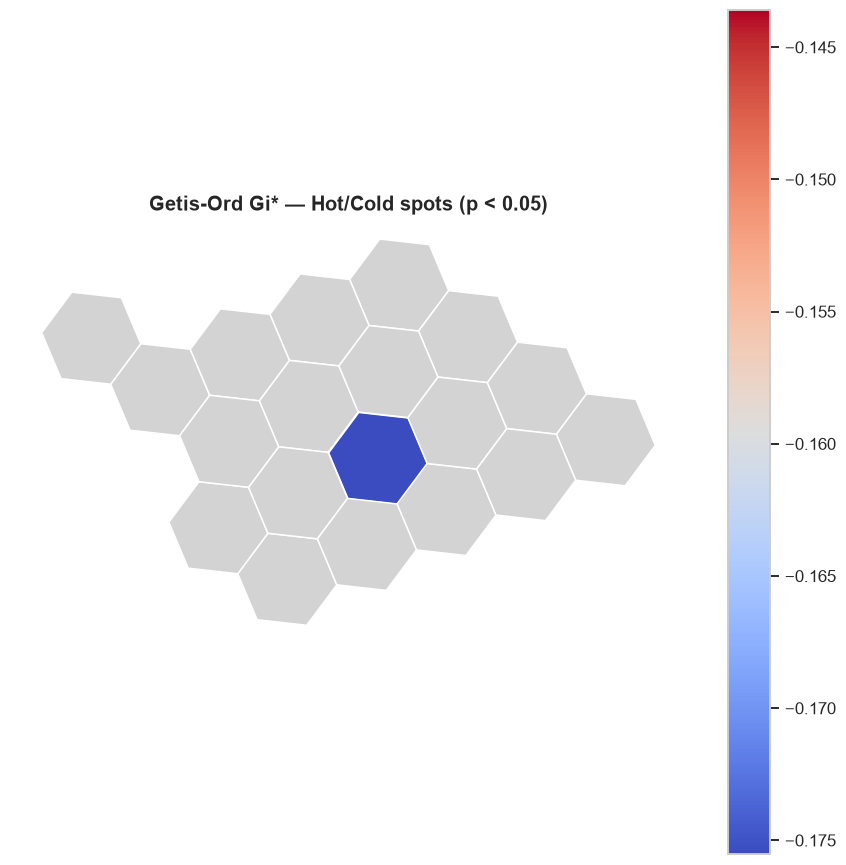


Resolución H3 = 8
Celdas H3 (res 8) cubriendo Iztapalapa: 134


C:\Users\jesus\AppData\Local\Temp\ipykernel_33976\3128644597.py:16: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = gdf_limite.geometry.unary_union


Celdas totales en la malla: 134
Celdas con al menos un incidente: 132
Moran's I global : -0.0462
p-value (sim)    : 0.2434
z-score (sim)    : -0.7151


d:\Lic Ciencia de Datos\TT C5\venv\Lib\site-packages\spreg\diagnostics.py:620: ComplexWarning: Casting complex values to real discards the imaginary part
  ci_result = sqrt(max_eigval / min_eigval)


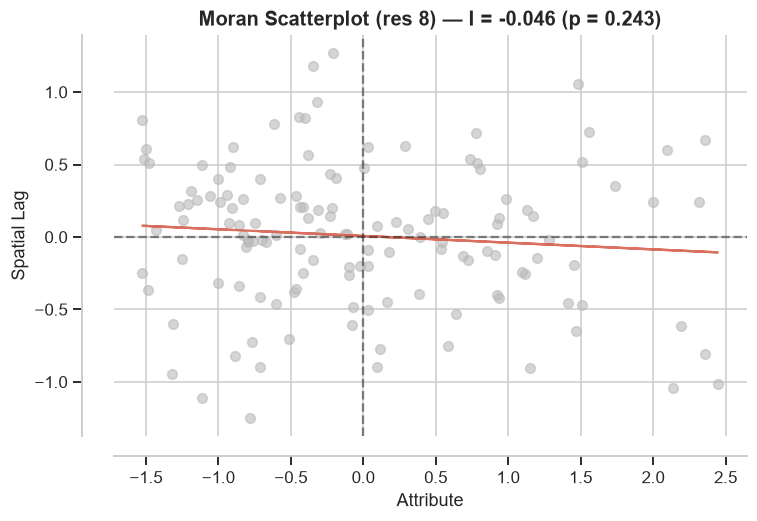

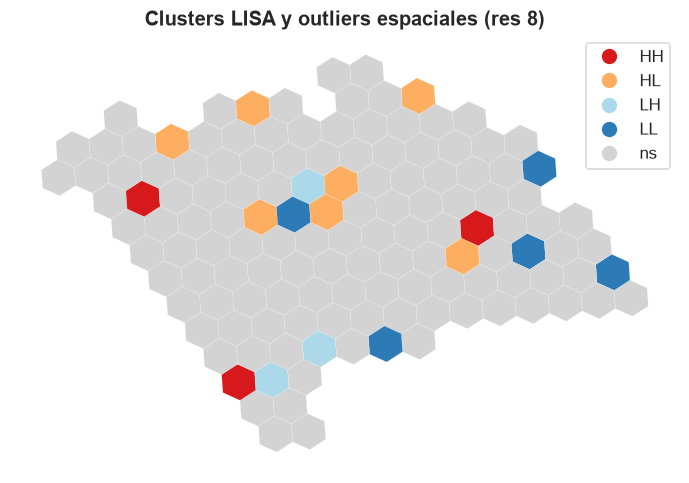

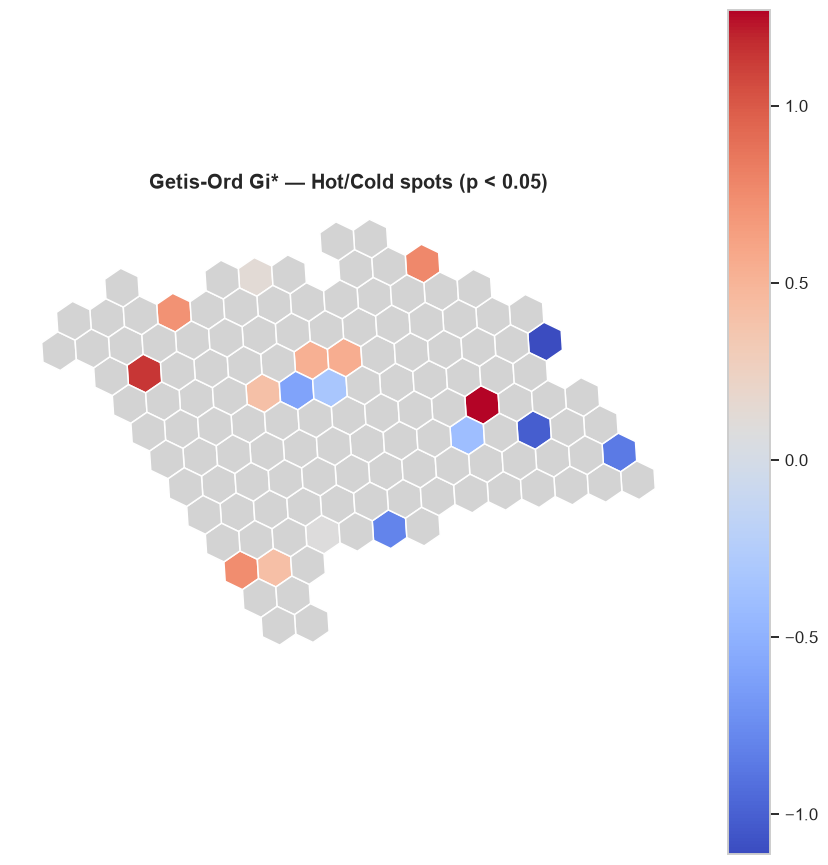


Resolución H3 = 9
Celdas H3 (res 9) cubriendo Iztapalapa: 931


C:\Users\jesus\AppData\Local\Temp\ipykernel_33976\3128644597.py:16: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = gdf_limite.geometry.unary_union


Celdas totales en la malla: 931
Celdas con al menos un incidente: 875
Moran's I global : -0.0338
p-value (sim)    : 0.0405
z-score (sim)    : -1.6876


d:\Lic Ciencia de Datos\TT C5\venv\Lib\site-packages\spreg\diagnostics.py:620: ComplexWarning: Casting complex values to real discards the imaginary part
  ci_result = sqrt(max_eigval / min_eigval)


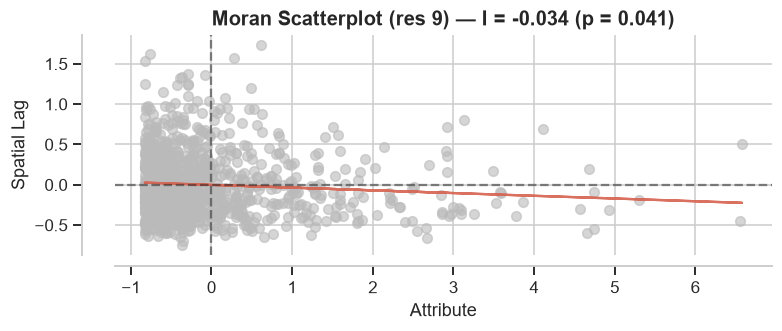

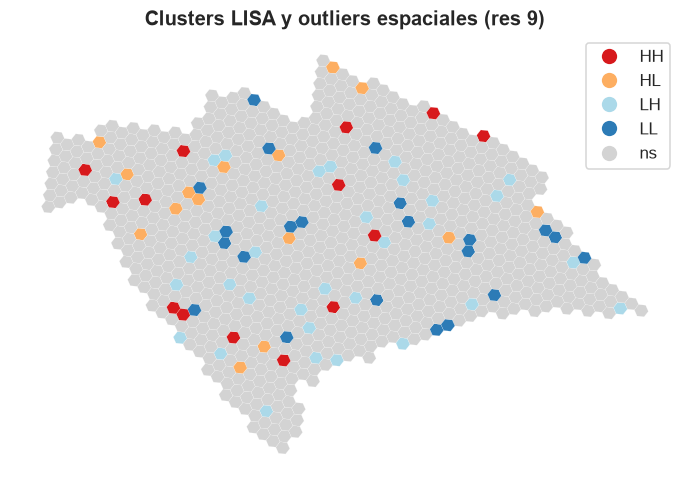

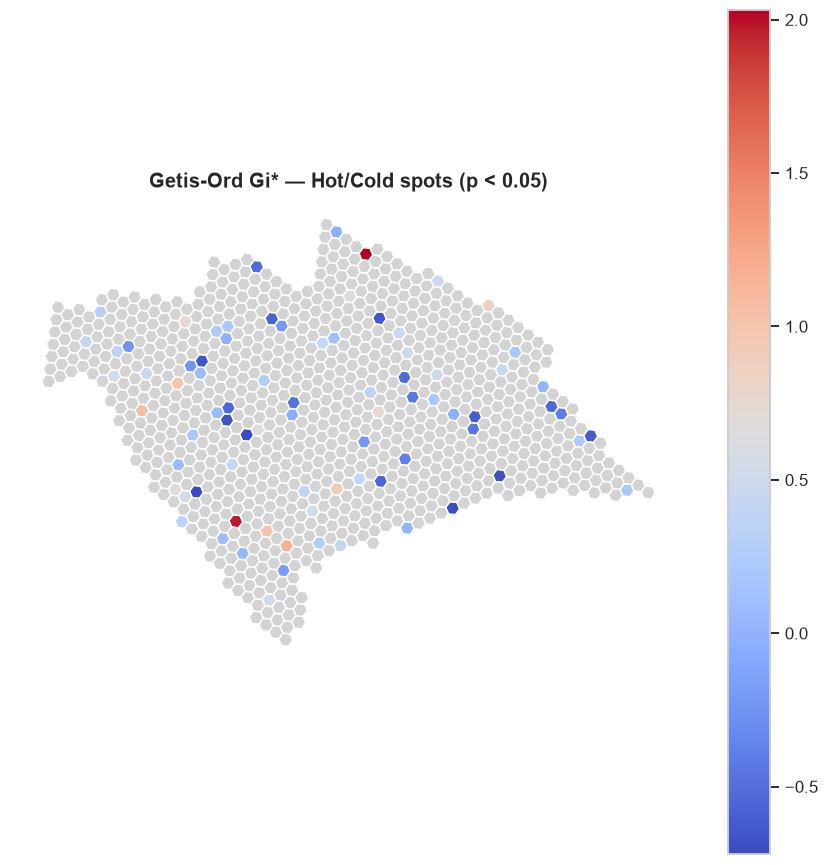


Resolución H3 = 10
Celdas H3 (res 10) cubriendo Iztapalapa: 6535


C:\Users\jesus\AppData\Local\Temp\ipykernel_33976\3128644597.py:16: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = gdf_limite.geometry.unary_union


Celdas totales en la malla: 6535
Celdas con al menos un incidente: 4317
Moran's I global : -0.0025
p-value (sim)    : 0.4024
z-score (sim)    : -0.3000


d:\Lic Ciencia de Datos\TT C5\venv\Lib\site-packages\spreg\diagnostics.py:620: ComplexWarning: Casting complex values to real discards the imaginary part
  ci_result = sqrt(max_eigval / min_eigval)


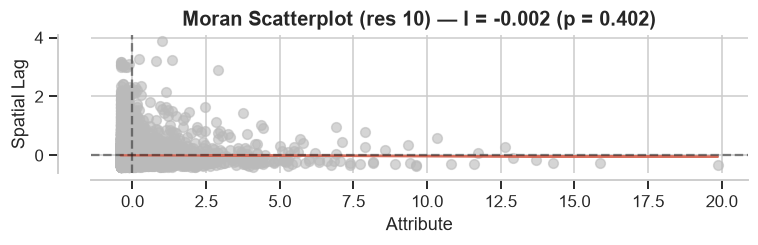

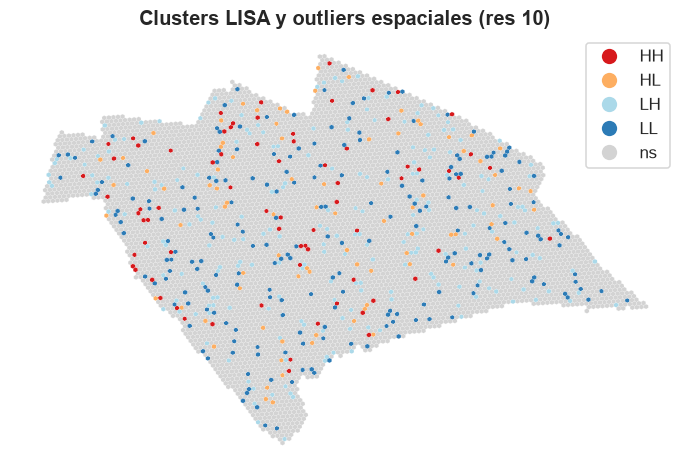

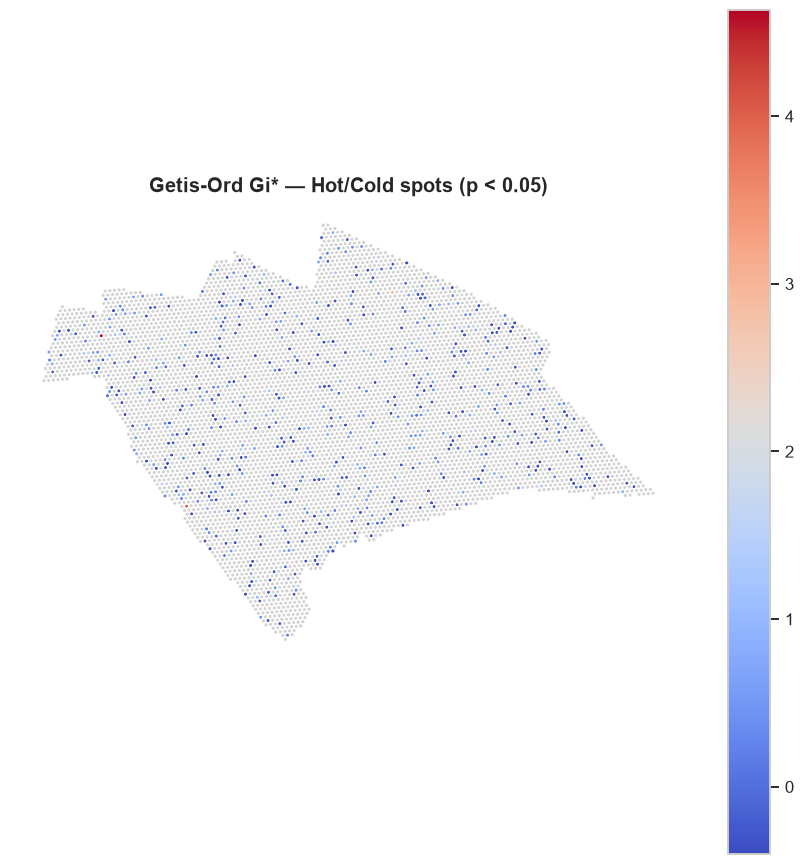


Resolución H3 = 11
Celdas H3 (res 11) cubriendo Iztapalapa: 45802


C:\Users\jesus\AppData\Local\Temp\ipykernel_33976\3128644597.py:16: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = gdf_limite.geometry.unary_union


Celdas totales en la malla: 45802
Celdas con al menos un incidente: 9781
Moran's I global : -0.0012
p-value (sim)    : 0.3638
z-score (sim)    : -0.4309


OSError: [WinError 1450] Recursos insuficientes en el sistema para completar el servicio solicitado

In [17]:
RESOLUCIONES_PRUEBA = [7, 8, 9, 10, 11, 12]
resultados_por_resolucion = {}

for res in RESOLUCIONES_PRUEBA:
    print(f"\n{'=' * 70}\nResolución H3 = {res}\n{'=' * 70}")

    celdas_malla_res = generar_malla_completa(iztapalapa_gdf, resolucion=res)
    print(f"Celdas H3 (res {res}) cubriendo Iztapalapa: {len(celdas_malla_res)}")

    df_res = asignar_celda_h3(df_filtrado, resolucion=res)
    gdf_res = construir_gdf_h3_completo(df_res, celdas_malla_res)
    print(f"Celdas totales en la malla: {len(gdf_res)}")
    print(f"Celdas con al menos un incidente: {(gdf_res['conteo_incidentes'] > 0).sum()}")

    w_res = construir_pesos_espaciales(gdf_res['h3_id'].tolist())

    y_res = gdf_res['conteo_incidentes'].values.astype(float)
    moran_res = prueba_moran_global(y_res, w_res)
    lisa_res = prueba_lisa(y_res, w_res)
    gi_res = prueba_getis_ord(y_res, w_res)

    gdf_res['lisa_cuadrante'] = lisa_res.q
    gdf_res['lisa_p'] = lisa_res.p_sim
    gdf_res['gi_z'] = gi_res.Zs
    gdf_res['gi_p'] = gi_res.p_sim

    resultados_por_resolucion[res] = {
        'gdf': gdf_res, 'w': w_res, 'moran': moran_res, 'lisa': lisa_res, 'gi': gi_res,
    }

    fig, ax = moran_scatterplot(moran_res, aspect_equal=True)
    ax.set_title(f"Moran Scatterplot (res {res}) — I = {moran_res.I:.3f} (p = {moran_res.p_sim:.3f})")
    plt.tight_layout()
    plt.show()

    fig, ax = lisa_cluster(lisa_res, gdf_res, p=0.05)
    ax.set_title(f"Clusters LISA y outliers espaciales (res {res})")
    plt.tight_layout()
    plt.show()

    mapa_hotspots_gi(gdf_res)

In [18]:
resumen_resoluciones = pd.DataFrame([
    {
        'resolucion': res,
        'n_celdas': len(r['gdf']),
        'celdas_con_incidentes': int((r['gdf']['conteo_incidentes'] > 0).sum()),
        'celdas_aisladas': len(r['w'].islands),
        'moran_I': r['moran'].I,
        'moran_p_sim': r['moran'].p_sim,
        'moran_z_sim': r['moran'].z_sim,
        'gi_significativas_p05': int((r['gdf']['gi_p'] < 0.05).sum()),
    }
    for res, r in resultados_por_resolucion.items()
])
resumen_resoluciones

,resolucion,n_celdas,celdas_con_incidentes,celdas_aisladas,moran_I,moran_p_sim,moran_z_sim,gi_significativas_p05
0,7,19,19,0,-0.062789,0.4898,-0.045394,1
1,8,134,132,0,-0.046232,0.2434,-0.715082,18
2,9,931,875,0,-0.033819,0.0405,-1.687640,79
3,10,6535,4317,0,-0.002488,0.4024,-0.300030,724
